 **STEP 1:  Install dependancies**

       !pip install transformers datasets faiss-cpu langchain langchain-community faiss-cpu sentence-transformers transformers pypdf

| Library                 | Description                                                                                                                                                 |
| ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `langchain`             | Core library for building applications with LLMs. Handles chaining, memory, agents, retrievers, tools, etc.                                                 |
| `langchain-community`   | Houses **connectors, integrations, and loaders** (e.g., Hugging Face models, file loaders like PDF, YouTube, etc.). Replaces older `langchain[docloaders]`. |
| `faiss-cpu`             | Fast Approximate Nearest Neighbor search. Used to **index and retrieve document chunks based on vector similarity**.                                        |
| `sentence-transformers` | Provides pretrained models (like `all-MiniLM`, `mpnet`) to convert text into **semantic embeddings**.                                                       |
| `transformers`          | Hugging Face’s core library to use LLMs like GPT-2, BERT, T5, Falcon, Mistral, etc. Used in the **generation step**.                                        |
| `pypdf`                 | Parses PDF files into text. Used with LangChain to load documents into the retriever.                                                                       |


In [1]:
#1. Install Required Libraries

!pip install langchain langchain-community faiss-cpu sentence-transformers transformers pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
# 2. We are going to build a Specific QA system - for example HR system
# Need to upload related documents.

from google.colab import files  # Special module in colab that allow you to upload a files from local system - dataset, pdf, images
uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

Saving HR Policy Manual 2023 (8).pdf to HR Policy Manual 2023 (8).pdf


In [3]:
# check the Path
print(pdf_path)

HR Policy Manual 2023 (8).pdf


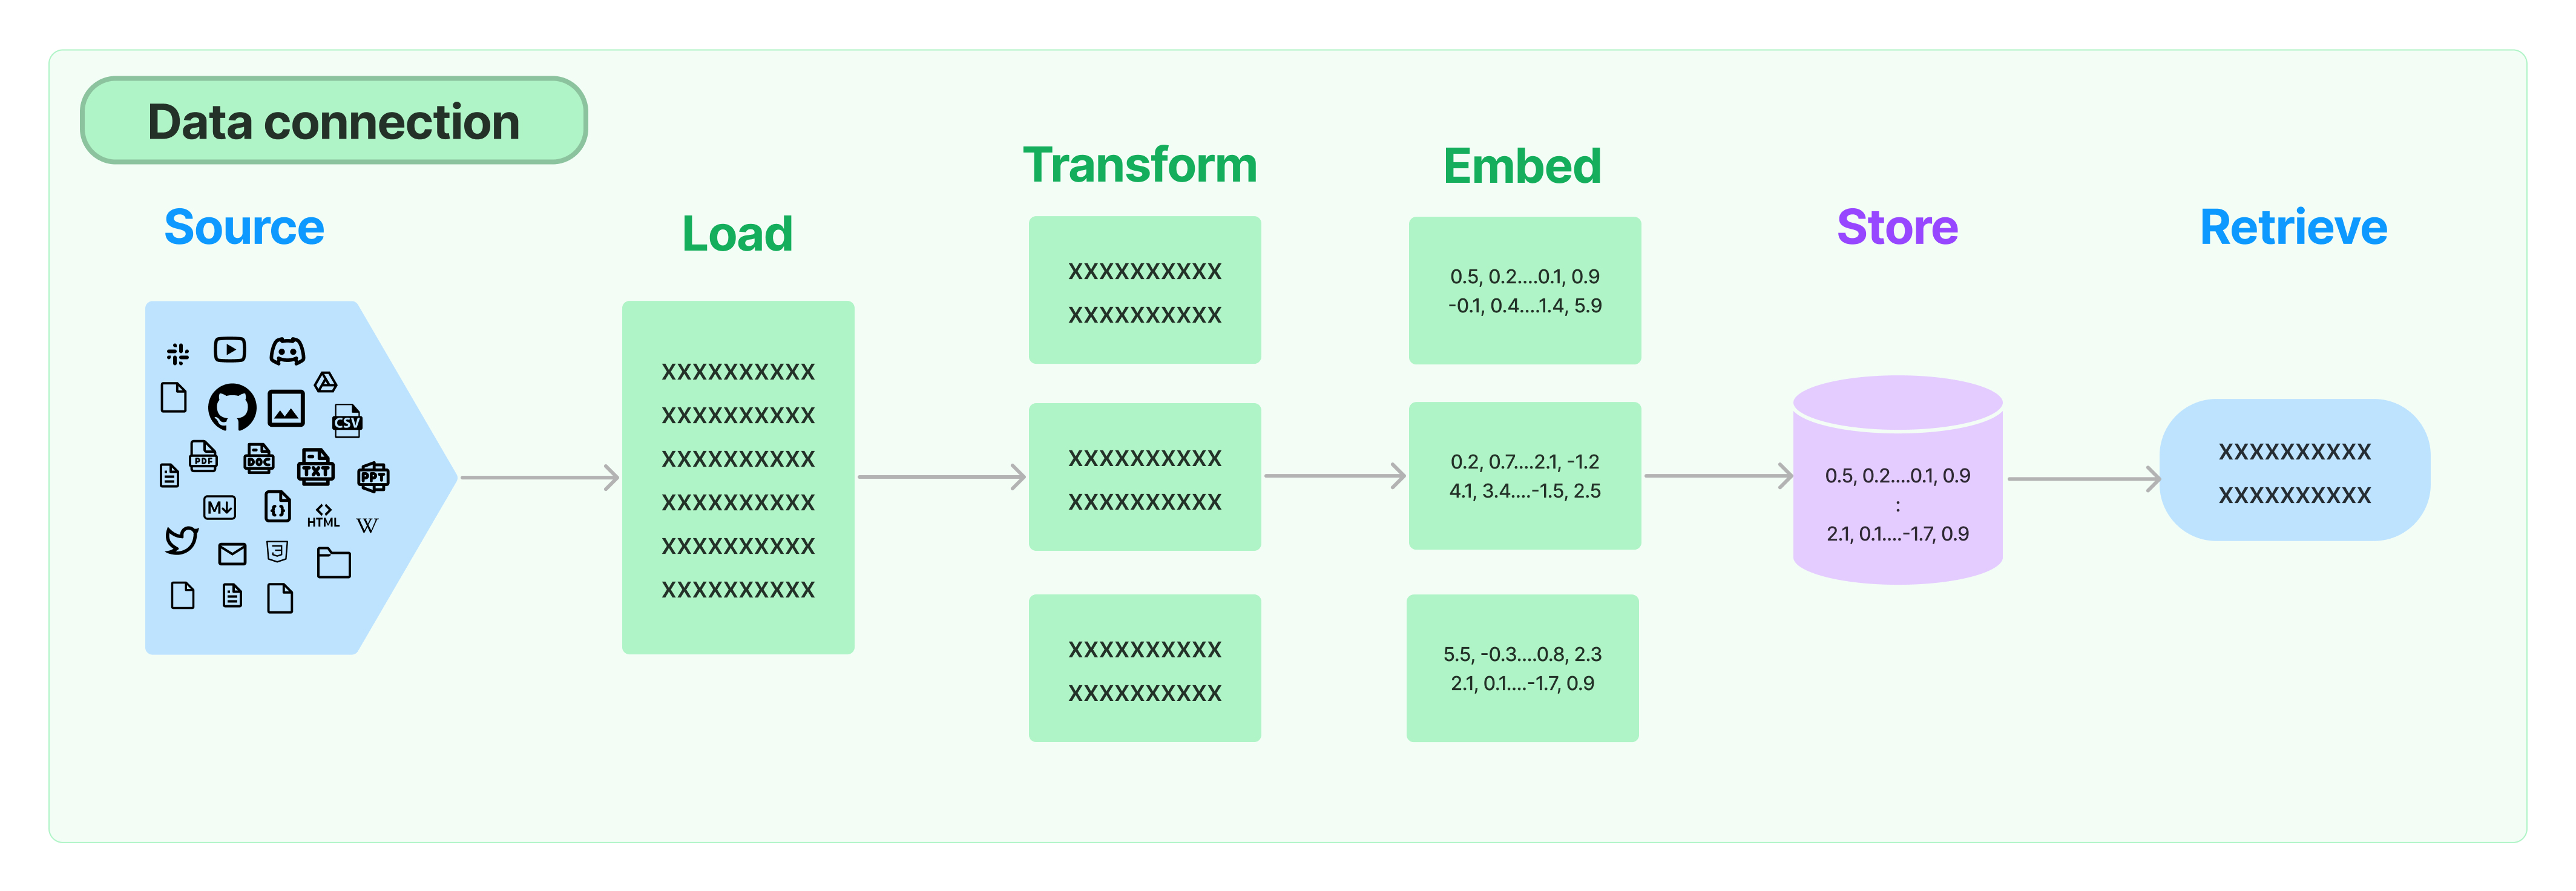

https://js.langchain.com/v0.1/docs/modules/data_connection/

In [4]:
#3. Load and Chunk the Document
#!pip install --upgrade --force-reinstall pydantic==1.10.13 langchain==0.1.20 langchain-community
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

loader = PyPDFLoader(pdf_path)
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
doc_chunks = splitter.split_documents(docs)

In [5]:
# langchain document format
print(docs)

[Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'total_pages': 208, 'page': 0, 'page_label': 'a'}, page_content='a\nIIMA HR Policy Manual 2023\nHUMAN RESOURCES  \nPOLICY MANUAL\nSTAFF \n2023'), Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'total_pages': 208, 'page': 1, 'page_label': 'b'}, page_content='b\nIIMA HR Policy Manual 2023'), Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'tota

In [6]:
# langchain document chunks
print(doc_chunks)

[Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'total_pages': 208, 'page': 0, 'page_label': 'a'}, page_content='a\nIIMA HR Policy Manual 2023\nHUMAN RESOURCES  \nPOLICY MANUAL\nSTAFF \n2023'), Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'total_pages': 208, 'page': 1, 'page_label': 'b'}, page_content='b\nIIMA HR Policy Manual 2023'), Document(metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'tota

In [7]:
# check somethings

docs[5].page_content

'iv\nIIMA HR Policy Manual 2023\nSpeeches/ Presentations In Public Seminars/ Conferences ...............................................45\nCommunications to the Media .........................................................................................................45\nProtection & Proper Use Of Iima Assets ......................................................................................45\nDrugs/Smoking/Alcohol/Weapons ...............................................................................................46\nConduct Rules ..........................................................................................................................................46\n[Do’s] – Every Employee Shall ..........................................................................................................46\n[Don’ts] No Employee Shall ...............................................................................................................46\nEmployee Arrested For Crimi

In [8]:
docs[5].metadata

{'producer': 'Adobe PDF Library 17.0',
 'creator': 'Adobe InDesign 18.1 (Windows)',
 'creationdate': '2023-01-27T09:40:38+05:30',
 'moddate': '2023-01-27T09:40:47+05:30',
 'trapped': '/False',
 'source': 'HR Policy Manual 2023 (8).pdf',
 'total_pages': 208,
 'page': 5,
 'page_label': 'iv'}

In [9]:
doc_chunks[0].page_content

'a\nIIMA HR Policy Manual 2023\nHUMAN RESOURCES  \nPOLICY MANUAL\nSTAFF \n2023'

- Langchain provides many document reader. Here I have pdf type document so used pyPDFLoader
- RecursiveCharacterTextSpliter used as Spliter. Splits long texts into smaller overlapping chunks, respecting sentence boundaries when possible. By default \n it uses a sentence boundry.
- chunk_size = 500 charater ~ 100-150 word, LLM window size 512-1024 words so almost good but can be increased or decreased based on the QA type.
- chunk_overlap = 50 to maintain continuity. Also not ideal.


In [10]:
!pip install langchain_huggingface

In [11]:
#. creating embeddings and storing them in a vector database (FAISS) for fast similarity search.

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(doc_chunks, embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

- Here I have used HuggingFaceEmbeddings from langchain to load llm for creating embeddings.
- This loads the **MiniLM sentence transformer from Hugging Face**.
- It's lightweight, fast, and very accurate for semantic search.
- Converts each text chunk into a 768-dimensional vector that captures its meaning.
- Converts all the doc_chunks into embeddings using the model.
- Stores them in a FAISS index, which supports fast nearest neighbor search.
- Returns a vectordb object that you can query later.
- Many VectorDB - FAISS, CromaDB, pinecone etc

In [13]:
print(f"Stored {vectordb.index.ntotal} chunks in the FAISS vector store.")

Stored 970 chunks in the FAISS vector store.


In [17]:
query = "What is the leave policy?"
retrieved_info = vectordb.similarity_search(query)
print("Retrieved Info:\n\n")
print(retrieved_info)

Retrieved Info:


[Document(id='c0350aa9-78bc-4621-b056-4f914f7eaddd', metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'total_pages': 208, 'page': 77, 'page_label': '68'}, page_content='or to leave the office early. \n(2) PROCEDURE FOR GRANTING LEAVE\n2.1 The grant of leave to the Institute employee is governed by the Institute Leave Rules.  These \nrules are framed in line with the leave rules applicable to the Central Government employees.\nCHAPTER 6\nLEAVE AND ATTENDANCE'), Document(id='163b386f-de7d-4f31-973d-7050c2a480a8', metadata={'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.1 (Windows)', 'creationdate': '2023-01-27T09:40:38+05:30', 'moddate': '2023-01-27T09:40:47+05:30', 'trapped': '/False', 'source': 'HR Policy Manual 2023 (8).pdf', 'total_pages': 208, 'page': 81, 

In [18]:
len(retrieved_info)

4

In [21]:
!pip install langchain-groq

In [24]:
# environment variable for groq

import os
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get('groq_api')

In [25]:
# 5. Seting up the LLM part of the RAG pipeline to generate natural language answers from retrieved document chunks

from langchain_groq import ChatGroq
from langchain_classic.chains import RetrievalQA


llm = ChatGroq(model="qwen/qwen3-32b")

qa = RetrievalQA.from_chain_type(llm, chain_type = "stuff", retriever=vectordb.as_retriever())

In [26]:
question = "What is the leave policy?"

answer = qa.invoke(question)

print(answer)
print(answer["result"])

{'query': 'What is the leave policy?', 'result': '<think>\nOkay, let\'s tackle the user\'s question about the leave policy. They want to know what the leave policy is based on the provided context.\n\nFirst, I need to go through the given context carefully. The context has several sections from the IIMA HR Policy Manual 2023, specifically under the "Leave and Attendance" chapter. \n\nStarting with section 2.1, it mentions that leave is governed by the Institute Leave Rules, which align with Central Government employee rules. That\'s a key point to include. \n\nNext, section 2.2 says leave can\'t be claimed as a right and might be denied based on the Institute\'s needs or public exigencies. So, the policy isn\'t automatic; it\'s at the discretion of the authority.\n\nSection 2.3 states that the leave sanctioning authority can refuse or revoke leaves but can\'t change the type of leave applied for. That\'s another important detail about the authority\'s power.\n\nSection 2.4 requires app

In [27]:
question = "What is the office hour?"
answer = qa.run(question)
print("Answer:", answer)

/tmp/ipykernel_40976/255969272.py:2: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 1.0. Use `invoke` instead.
  answer = qa.run(question)


Answer: <think>
Okay, the user is asking about the office hours. Let me check the provided context.

Looking at section 1.1, it says the Institute timings are from 9:00 am to 5:45 pm on Monday to Friday. There's also a 15-minute grace period in the morning for delays. So the standard office hours are 9 AM to 5:45 PM, with a 15-minute flexibility at the start. 

Other sections mention lunch breaks for staff between 1:00 pm to 1:45 pm, but that's part of the staff's schedule, not the overall office hours. The main info is in 1.1. Also, shift-based staff have different timings decided by the HoD, but the general answer is the standard 9-5:45. The user didn't specify shifts, so the default applies. Need to mention the grace period as part of the answer as well.
</think>

The office hours at the Institute are from **9:00 am to 5:45 pm** on Monday to Friday. A **15-minute grace period** is provided in the morning for unforeseen delays, as per the rules outlined in the HR Policy Manual 2023.


In [28]:
question ="How many casual leaves are allowed?"
answer = qa.run(question)
print("Answer:", answer)

Answer: <think>
Okay, let's tackle the user's question: "How many casual leaves are allowed?" 

First, I need to refer to the provided context. The user mentioned sections 4 and 5, but specifically section 5.1 which is about Casual Leave. 

Looking at 5.1.1, it states that an employee is entitled to eight days of casual leave in a calendar year. The key points here are the total allowed per year and the condition that no more than five days can be taken at a time. Also, 5.1.7 mentions that casual leave cannot be accumulated and lapses if not used in the year. 

I should check if there are any exceptions. 5.1.8 and 5.1.9 talk about employees appointed on a term basis or those joining mid-year getting proportional leave. But the user is asking about the standard number, so those might be additional info but not the main answer here.

The user is asking for the number, so the answer is eight days per year. Also, need to mention the maximum five days at a time. The other points like not co

In [29]:
question ="What is the dress code?"
answer = qa.run(question)
print("Answer:", answer)

Answer: <think>
Okay, the user is asking about the dress code. Let me check the provided context.

Looking through the documents, there's a section titled "Uniforms" under the IIMA HR Policy Manual 2023. It mentions two sets per child per academic year. Then there are points about school shoes, text books, note books, etc. 

Further down, there's a list that includes items like Shock Proof Shoes for technicians, Rainy Sandal, Summer Cap, Socks, Woollen Uniform, and Rain Coat with quantities and durations. It also mentions that the HR Department submits a list of employees for procuring these items. 

Additionally, under the "WASHING ALLOWANCE" section, it states that Group D employees receive Rs 90 per month. But the main dress code elements seem to be in the earlier list. 

The user might be an employee or a student needing to know what to wear. Since the first part mentions uniforms for children, but the later list includes items for employees (like Shock Proof Shoes for technicians)

In [30]:
question ="What is the leave policy for new employee?"
answer = qa.run(question)
print("Answer:", answer)

Answer: <think>
Okay, the user is asking about the leave policy for a new employee. Let me look through the provided context to find relevant information.

First, the context mentions that leave is governed by the Institute Leave Rules, which are similar to those for Central Government employees. So, new employees would follow these rules. 

There's a section 5.5.12 that states no leave can be granted for more than five years continuously. However, that might apply to permanent employees, and new employees might not be permanent yet. 

Section 2.6 says that after a leave over ten days, you report to the HoD and HR. But if the new employee is just starting, they might not take leave immediately. 

Section 2.7 requires leave applications through ESS in the same month. So new employees would need to use the ESS system once they're onboard. 

Also, section 4 mentions that the Institute can end an employee's tenure with notice or pay in lieu. This might relate to probationary periods for ne